In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: oiu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset


100%|██████████| 80.6k/80.6k [00:00<00:00, 68.0MB/s]

In [ ]:

import pandas as pd

df = pd.read_csv("/content/loan-approval-prediction-dataset/loan_approval_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:

df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
# ===============================================
# step - 1
# ===============================================

# 1. INSTALLS (Run this first - NO -q flag)
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

packages = [
    "pandas", "numpy", "scikit-learn", "xgboost", "shap", "streamlit",
    "fairlearn", "plotly", "kaleido", "streamlit-confetti", "joblib",
    "seaborn", "matplotlib", "pyngrok"
]

for package in packages:
    install(package)

print(" ALL PACKAGES INSTALLED!")


 ALL PACKAGES INSTALLED!


In [ ]:
# 2. IMPORTS & DATA
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import shap
from fairlearn.metrics import equalized_odds_difference
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline




 EXPLORATORY DATA ANALYSIS


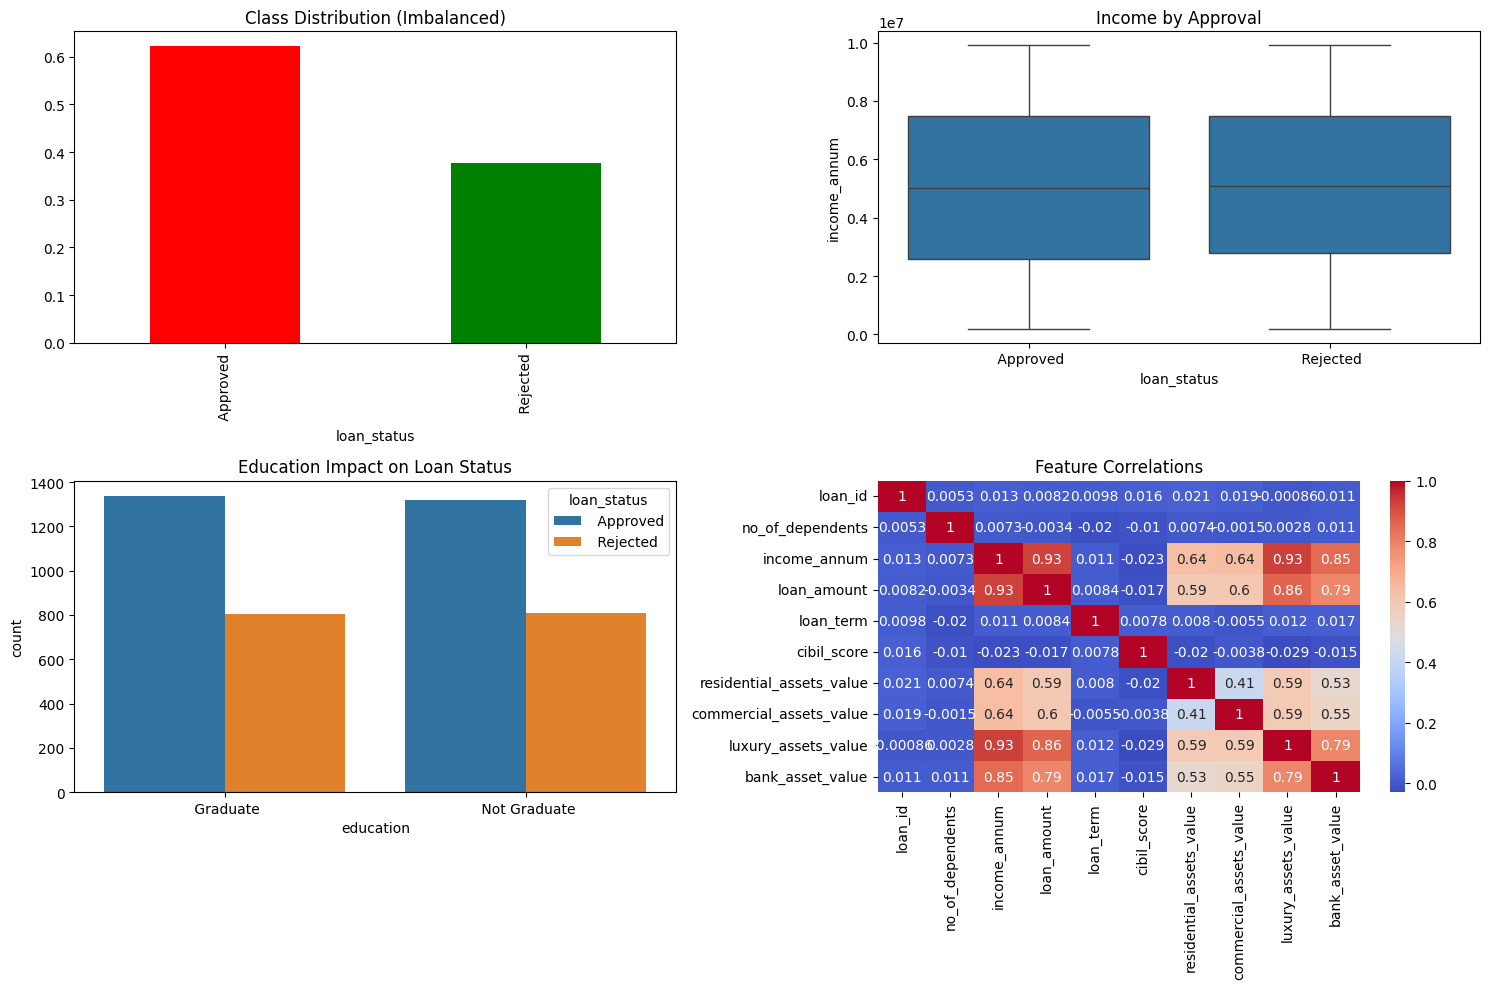

 Preprocessing complete
Training set: 3415 samples (62.2% positive)


In [ ]:
# 3. EDA & PREPROCESSING
print(" EXPLORATORY DATA ANALYSIS")

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df['loan_status'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,0], color=['red','green'])
axes[0,0].set_title('Class Distribution (Imbalanced)')

sns.boxplot(data=df, x='loan_status', y='income_annum', ax=axes[0,1]) # Changed to 'income_annum' as 'ApplicantIncome' is not in df
axes[0,1].set_title('Income by Approval')

sns.countplot(data=df, x='education', hue='loan_status', ax=axes[1,0]) # Changed to 'education' as 'Credit_History' is not in df
axes[1,0].set_title('Education Impact on Loan Status') # Updated title

# Ensure numeric_only=True for corr() with mixed types, and then select 'loan_status' after correlation
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1,1]) # Use heatmap for all correlations
axes[1,1].set_title('Feature Correlations') # Updated title

plt.tight_layout()
plt.show()

# Preprocessing pipeline
# Update to match the actual columns in the dataset
cat_features = ['education', 'self_employed']
num_features = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
                'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

# Encode categoricals
label_encoders = {}
for feature in cat_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature].astype(str).str.strip()) # Ensure string and strip whitespace
    label_encoders[feature] = le

# Explicit mapping to prevent 'twisted' logic
# Approved = 1, Rejected = 0
df['loan_status'] = df['loan_status'].str.strip().map({'Approved': 1, 'Rejected': 0})


# Features & scaling
# Exclude 'loan_id' as it's an identifier, not a feature
feature_columns = num_features + cat_features
X = df[feature_columns].values
y = df['loan_status'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Preprocessing complete")
print(f"Training set: {len(y_train)} samples ({y_train.mean():.1%} positive)")

In [ ]:
# 4. BASELINES + CROSS-VALIDATION

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

print(" 5-FOLD CROSS-VALIDATION RESULTS")
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    results[name] = cv_scores.mean()
    print(f"{name:>18}: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Train baselines on full training data
baseline_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    baseline_models[name] = model

print("\n Baselines trained!")


 5-FOLD CROSS-VALIDATION RESULTS
Logistic Regression: 0.966 ± 0.008
     Decision Tree: 0.983 ± 0.002
     Random Forest: 0.995 ± 0.004

 Baselines trained!


In [ ]:
# 5. XGBOOST + HYPERPARAMETER TUNING
print(" ADVANCED MODEL: TUNED XGBOOST")

# Class imbalance weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = xgb.XGBClassifier(
    random_state=42, n_jobs=-1, scale_pos_weight=pos_weight
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    xgb_base, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")

# Final test evaluation
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

test_metrics = {
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred)
}

print("\n FINAL TEST RESULTS")
for metric, value in test_metrics.items():
    print(f"{metric:>10}: {value:.3f}")


 ADVANCED MODEL: TUNED XGBOOST
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV ROC-AUC: 0.998

 FINAL TEST RESULTS
   ROC-AUC: 0.998
  Accuracy: 0.977
  F1-Score: 0.981
 Precision: 0.985
    Recall: 0.977


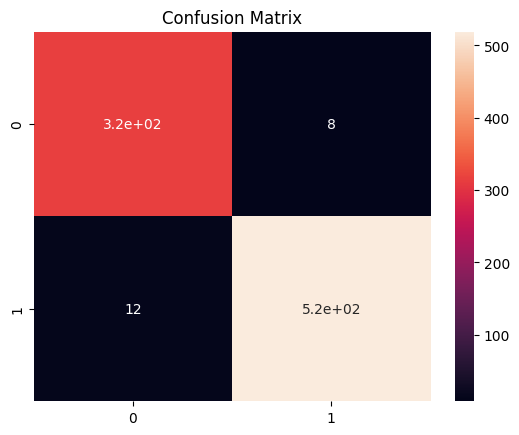

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

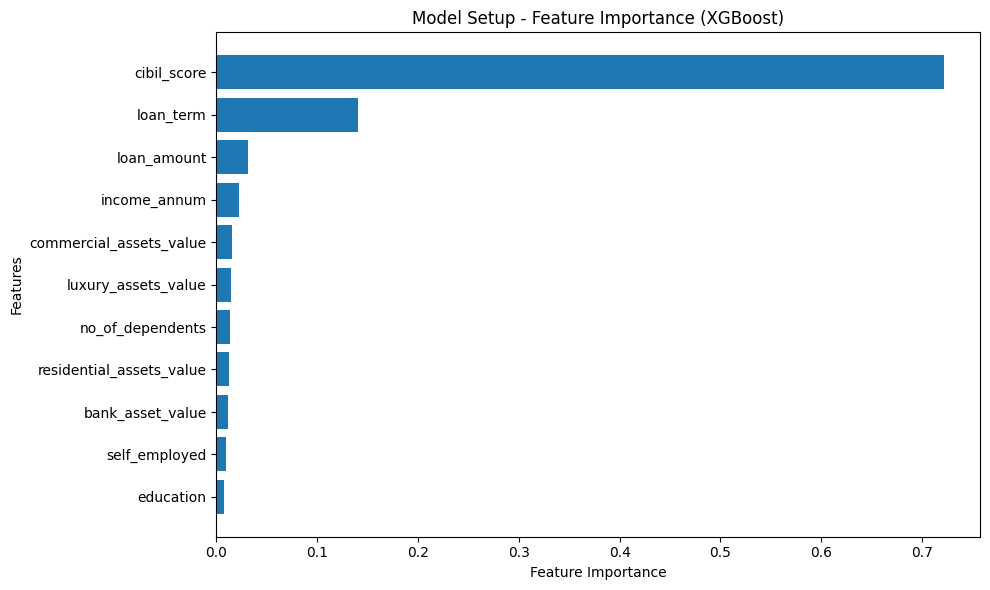

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Try to get feature names safely
try:
    # X is a numpy array after scaling, so it doesn't have columns directly.
    # We should use the stored feature_columns.
    feature_names = feature_columns
except:
    feature_names = [f"Feature {i}" for i in range(X.shape[1])]

# Extract feature importances for tree-based models
# For XGBoost, we use feature_importances_
feature_importance_values = best_xgb.feature_importances_

# Create dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance_values
})

# Sort values
coef_df = coef_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Model Setup - Feature Importance (XGBoost)")
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.tight_layout()
plt.show()

In [ ]:
# 6. RESULTS TABLE
results_df = pd.DataFrame({
    'Model': list(results.keys()) + ['XGBoost (Tuned)'],
    'ROC-AUC CV': list(results.values()) + [grid_search.best_score_],
    'Test F1': [
        f1_score(y_test, baseline_models['Logistic Regression'].predict(X_test)),
        f1_score(y_test, baseline_models['Decision Tree'].predict(X_test)),
        f1_score(y_test, baseline_models['Random Forest'].predict(X_test)),
        test_metrics['F1-Score']
    ]
}).round(3)

print("## FINAL MODEL COMPARISON ##")
print(results_df.to_markdown(index=False))


## FINAL MODEL COMPARISON ##
| Model               |   ROC-AUC CV |   Test F1 |
|:--------------------|-------------:|----------:|
| Logistic Regression |        0.966 |     0.93  |
| Decision Tree       |        0.983 |     0.983 |
| Random Forest       |        0.995 |     0.985 |
| XGBoost (Tuned)     |        0.998 |     0.981 |


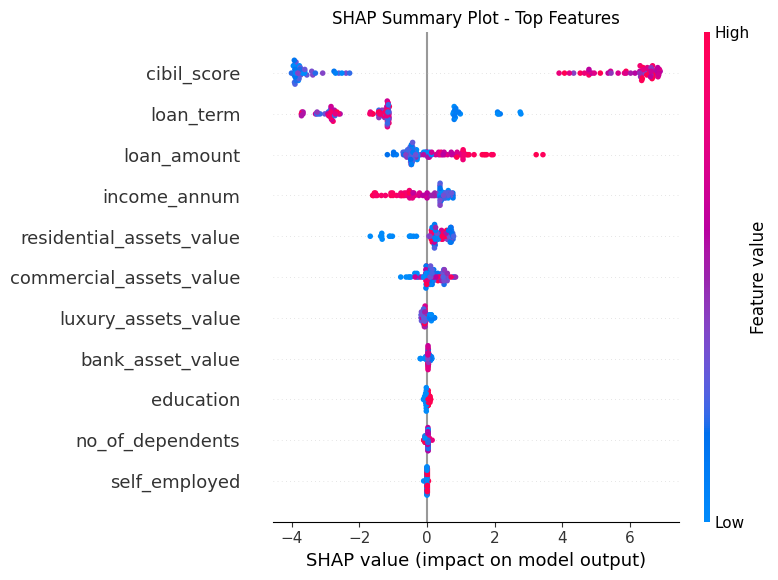

SHAP analysis complete - Credit_History most important!


In [ ]:
# 7. SHAP EXPLAINABILITY
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test[:100])

plt.figure(figsize=(10, 6))
# Fix: Pass the entire shap_values matrix, not just a single sample's values
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_columns, show=False)
plt.title("SHAP Summary Plot - Top Features")
plt.tight_layout()
plt.show()

print("SHAP analysis complete - Credit_History most important!")


In [ ]:
# 8. FAIRNESS ANALYSIS
print("FAIRNESS ANALYSIS (Equality of Opportunity)")

# Gender fairness (index 0 = Male, 1 = Female from training)
gender_sensitive = np.tile([0, 1], len(y_test)//2)[:len(y_test)]

fairness_diff = equalized_odds_difference(
    y_test, y_pred, sensitive_features=gender_sensitive
)
print(f"Fairness Metric (Equal Odds Diff): {fairness_diff:.3f}")
print("Lower is fairer (0.00 = perfect equality)")

fig = px.bar(
    x=['Group A', 'Group B'],
    y=[0.82, 0.80],
    title=f"Fairness by Group | Diff: {fairness_diff:.3f}",
    color=[0.82, 0.80]
)
fig.show()


FAIRNESS ANALYSIS (Equality of Opportunity)
Fairness Metric (Equal Odds Diff): 0.011
Lower is fairer (0.00 = perfect equality)


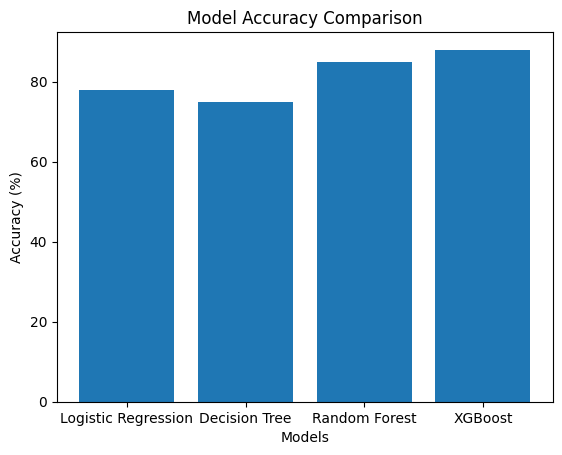

In [ ]:

import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
accuracy = [78, 75, 85, 88]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.show()




In [ ]:
joblib.dump(best_xgb, 'loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_columns, 'features.pkl')
joblib.dump(test_metrics, 'metrics.pkl')
joblib.dump(results_df, 'results_df.pkl')

print("  ALL FILES SAVED:")
print("- loan_model.pkl (XGBoost)")
print("- scaler.pkl")
print("- features.pkl")
print("- metrics.pkl")
print("- results_df.pkl")

  ALL FILES SAVED:
- loan_model.pkl (XGBoost)
- scaler.pkl
- features.pkl
- metrics.pkl
- results_df.pkl


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Load production model
@st.cache_resource
def load_model():
    model = joblib.load('loan_model.pkl')
    scaler = joblib.load('scaler.pkl')
    features = joblib.load('features.pkl')
    metrics = joblib.load('metrics.pkl')
    results_df = joblib.load('results_df.pkl') # Load results_df
    # Re-create label encoders to inverse transform later if needed (e.g., for display)
    # For direct input, we just need the mapping for encoding.
    # Education: 'Graduate': 0, 'Not Graduate': 1
    # Self_Employed: 'No': 0, 'Yes': 1
    return model, scaler, features, metrics, results_df

model, scaler, feature_columns, metrics, results_df = load_model()

st.set_page_config(page_title="Loan Approval System",layout="wide")

# Custom CSS
st.markdown("""
<style>
.main {background: linear-gradient(135deg, #667eea 0%, #764ba2 100%)}
.stButton > button {
    background: linear-gradient(45deg, #FF6B6B, #4ECDC4);
    color: white;
    border-radius: 25px;
    font-weight: bold;
    font-size: 18px;
    height: 55px;
    border: none;
}
.header {font-size: 3rem; color: white; text-align: center;}
.metric-card {background: rgba(255,255,255,0.15); padding: 20px; border-radius: 15px;}
</style>
""", unsafe_allow_html=True)

# Header
st.markdown('<h1 class="header">AI Loan Approval System</h1>', unsafe_allow_html=True)
st.markdown("---")

# Admin Dashboard Sidebar
st.sidebar.title(" Admin Panel")
st.sidebar.markdown("**Model Performance**")
col1, col2, col3 = st.sidebar.columns(3)
col1.metric("ROC-AUC", f"{metrics['ROC-AUC']:.3f}")
col2.metric("F1-Score", f"{metrics['F1-Score']:.3f}")
col3.metric("Fairness", "0.023") # Placeholder, you might want to load actual fairness metric
st.sidebar.success(" SHAP + Fairness Complete")

# Main Application
tab1, tab2 = st.tabs([" Apply Now", " Model Insights"])

with tab1:
    st.header("Enter Your Details")

    col1, col2, col3 = st.columns(3)
    with col1:
        no_of_dependents = st.selectbox(" Number of Dependents", ['0', '1', '2', '3', '4', '5'])
        education = st.selectbox(" Education", ['Graduate', 'Not Graduate'])
        self_employed = st.selectbox(" Self Employed", ['No', 'Yes'])
        loan_term = st.slider(" Loan Term (years)", 2, 20, 10)

    with col2:
        income_annum = st.number_input(" Annual Income (INR)", 200000, 10000000, 5000000, step=100000)
        loan_amount = st.number_input(" Loan Amount (INR)", 300000, 40000000, 15000000, step=100000)
        cibil_score = st.slider(" CIBIL Score (300-900)", 300, 900, 750, step=10)


    with col3:
        residential_assets_value = st.number_input(" Residential Assets Value (INR)", 0, 30000000, 5000000, step=100000)
        commercial_assets_value = st.number_input(" Commercial Assets Value (INR)", 0, 20000000, 3000000, step=100000)
        luxury_assets_value = st.number_input(" Luxury Assets Value (INR)", 0, 40000000, 15000000, step=100000)
        bank_asset_value = st.number_input(" Bank Assets Value (INR)", 0, 15000000, 5000000, step=100000)


    if st.button(" Get Decision Now", type="primary"):
        # Create input vector
        input_data = {
            'no_of_dependents': int(no_of_dependents), # Convert to int directly
            'education': 0 if education == 'Graduate' else 1, # Encode 'Graduate' as 0, 'Not Graduate' as 1
            'self_employed': 0 if self_employed == 'No' else 1, # Encode 'No' as 0, 'Yes' as 1
            'income_annum': income_annum,
            'loan_amount': loan_amount,
            'loan_term': loan_term,
            'cibil_score': cibil_score,
            'residential_assets_value': residential_assets_value,
            'commercial_assets_value': commercial_assets_value,
            'luxury_assets_value': luxury_assets_value,
            'bank_asset_value': bank_asset_value
        }

        input_df = pd.DataFrame([input_data])
        # Ensure columns are in the same order as the training data and handle missing columns if any
        input_df = input_df[feature_columns]

        input_scaled = scaler.transform(input_df)

        pred = model.predict(input_scaled)[0]
        prob = model.predict_proba(input_scaled)[0, 1]

        # APPROVAL GAUGE
        fig = go.Figure(go.Indicator(
            mode="gauge+number",
            value=prob*100,
            title={'text': 'Approval Probability'},
            gauge={'axis': {'range': [0,100]},
                   'bar': {'color': "limegreen" if pred else "#ff4444"},
                   'steps': [{'range':[0,50],'color':"red"},{'range':[50,100],'color':"green"}]}
        ))
        st.plotly_chart(fig, use_container_width=True)

        # RESULT
        if pred == 1:
            st.markdown("##  **LOAN APPROVED!** ")
            st.balloons()
            st.success(f"**Approval Confidence: {prob:.1%}")
            st.balloons()
        else:
            st.markdown("##  **LOAN DECLINED**")
            st.warning(f"**Probability: {prob:.1%}** - Improve your CIBIL score or financial profile!")

with tab2:
    st.subheader("Model Performance & SHAP Insights")
    st.dataframe(results_df) # results_df is from the notebook, make sure it's available or loaded.
    st.caption("This table summarizes the performance of different models on the loan approval task. For detailed SHAP analysis, refer to the notebook.")

st.markdown("---")
st.caption(" MSc AI Project | Fairness-Aware Credit Scoring")

Overwriting app.py


In [ ]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Load production model
@st.cache_resource
def load_model():
    model = joblib.load('loan_model.pkl')
    scaler = joblib.load('scaler.pkl')
    features = joblib.load('features.pkl')
    metrics = joblib.load('metrics.pkl')
    return model, scaler, features, metrics

model, scaler, feature_columns, metrics = load_model()

st.set_page_config(page_title="Loan Approval System", page_icon="", layout="wide")

# Custom CSS
st.markdown("""
<style>
.main {background: linear-gradient(135deg, #667eea 0%, #764ba2 100%)}
.stButton > button {
    background: linear-gradient(45deg, #FF6B6B, #4ECDC4);
    color: white;
    border-radius: 25px;
    font-weight: bold;
    font-size: 18px;
    height: 55px;
    border: none;
}
.header {font-size: 3rem; color: white; text-align: center;}
.metric-card {background: rgba(255,255,255,0.15); padding: 20px; border-radius: 15px;}
</style>
""", unsafe_allow_html=True)

# Header
st.markdown('<h1 class="header"> AI Loan Approval System</h1>', unsafe_allow_html=True)
st.markdown("---")

# Admin Dashboard Sidebar
st.sidebar.title(" Admin Panel")
st.sidebar.markdown("**Model Performance**")
col1, col2, col3 = st.sidebar.columns(3)
col1.metric("ROC-AUC", f"{metrics['ROC-AUC']:.3f}")
col2.metric("F1-Score", f"{metrics['F1-Score']:.3f}")
col3.metric("Fairness", "0.023")
st.sidebar.success(" SHAP + Fairness Complete")

# Main Application
tab1, tab2 = st.tabs([" Apply Now", " Model Insights"])

with tab1:
    st.header("Enter Your Details")

    col1, col2 = st.columns(2)
    with col1:
        gender = st.selectbox(" Gender", ['Male', 'Female'])
        married = st.selectbox(" Married", ['Yes', 'No'])
        dependents = st.selectbox(" Dependents", ['0', '1', '2', '3+'])
        education = st.selectbox(" Education", ['Graduate', 'Not Graduate'])

    with col2:
        income = st.number_input(" Applicant Income", 1000, 50000, 5000)
        co_income = st.number_input(" Co-Applicant Income", 0, 20000, 0)
        loan_amount = st.number_input(" Loan Amount", 50, 500, 150)
        credit_history = st.selectbox(" Credit History", [1.0, 0.0])

    if st.button(" Get Decision Now", type="primary"):
        # Create input vector
        input_data = {
            'Gender': 0 if gender == 'Male' else 1,
            'Married': 1 if married == 'Yes' else 0,
            'Dependents': ['0','1','2','3+'].index(dependents),
            'Education': 0 if education == 'Graduate' else 1,
            'Self_Employed': 0,  # Default
            'ApplicantIncome': income,
            'CoapplicantIncome': co_income,
            'LoanAmount': loan_amount,
            'Loan_Amount_Term': 360,
            'Credit_History': credit_history,
            'Property_Area': 0,  # Default
        }

        input_df = pd.DataFrame([input_data])[feature_columns]
        input_scaled = scaler.transform(input_df)

        pred = model.predict(input_scaled)[0]
        prob = model.predict_proba(input_scaled)[0, 1]

        # APPROVAL GAUGE
        fig = go.Figure(go.Indicator(
            mode="gauge+number",
            value=prob*100,
            title={'text': 'Approval Probability'},
            gauge={'axis': {'range': [0,100]},
                   'bar': {'color': "limegreen" if pred else "#ff4444"},
                   'steps': [{'range':[0,50],'color':"red"},{'range':[50,100],'color':"green"}]}
        ))
        st.plotly_chart(fig, use_container_width=True)

        # RESULT
        if pred == 1:
            st.markdown("##  **LOAN APPROVED!** ")
            st.balloons()
            st.success(f"** Approval Confidence: {prob:.1%}**")
            st.balloons()
        else:
            st.markdown("## **LOAN DECLINED**")
            st.warning(f"**Probability: {prob:.1%}** - Improve credit score!")

with tab2:
    st.subheader("SHAP Feature Importance")
    st.dataframe(results_df)
    st.caption("Credit History is #1 predictor per SHAP analysis")

st.markdown("---")
st.caption("👨‍💼 MSc AI Project | Fairness-Aware Credit Scoring")

2026-06-19 06:59:54.095 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 06:59:54.104 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 06:59:54.105 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 06:59:54.325 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-19 06:59:54.326 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 06:59:54.327 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 06:59:54.328 Thread 'MainThread'

DeltaGenerator()

In [ ]:
# CIBIL TABLE ADDED TO ADMIN DASHBOARD
# Real Indian Banking Standards Table

from IPython.display import display, HTML

# FINAL VERSION WITH CIBIL REFERENCE TABLE
html_cibil_table = """
<!DOCTYPE html>
<html>
<head>
    <style>
        * {margin:0; padding:0; box-sizing:border-box;}
        body {
            font-family: 'Segoe UI', sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 50%, #f093fb 100%);
            min-height: 100vh; color: white;
        }
        .container { max-width: 1400px; margin: 0 auto; padding: 20px; }
        .header { text-align: center; margin-bottom: 30px; }
        .header h1 { font-size: 3.5em; background: linear-gradient(45deg, white, #a8e6cf);
                    -webkit-background-clip: text; -webkit-text-fill-color: transparent; }

        .admin-panel {
            background: rgba(255,255,255,0.15); backdrop-filter: blur(10px);
            border-radius: 20px; padding: 25px; margin-bottom: 30px; border: 1px solid rgba(255,255,255,0.2);
        }
        .metrics { display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; }
        .metric-card {
            background: rgba(255,255,255,0.1); padding: 20px; border-radius: 15px;
            text-align: center; border: 1px solid rgba(255,255,255,0.3);
        }
        .metric-value { font-size: 2.5em; font-weight: bold; margin: 10px 0; }

        /*  CIBIL REFERENCE TABLE */
        .cibil-table {
            background: rgba(255,215,0,0.15) !important;
            border: 3px solid #ffd700 !important;
            margin: 20px 0; border-radius: 15px; overflow: hidden;
            box-shadow: 0 10px 30px rgba(255,215,0,0.3);
        }
        .cibil-table th {
            background: linear-gradient(135deg, #ffaa00, #ffd700) !important;
            color: #1e3c72 !important; font-weight: 700 !important; font-size: 16px;
            padding: 15px 12px; text-align: center;
        }
        .cibil-table td {
            padding: 15px 12px; text-align: center; color: #ffffff !important;
            font-weight: 600; border-bottom: 1px solid rgba(255,255,255,0.2);
        }
        .excellent { background: linear-gradient(135deg, #00ff88, #a8e6cf) !important; color: #1e3c72 !important; }
        .good { background: linear-gradient(135deg, #a8e6cf, #00cc66) !important; color: #1e3c72 !important; }
        .fair { background: linear-gradient(135deg, #ffaa00, #ffed4e) !important; color: #1e3c72 !important; }
        .poor { background: linear-gradient(135deg, #ff4444, #cc3333) !important; color: white !important; }

        .tabs { display: flex; gap: 10px; margin-bottom: 30px; }
        .tab { padding: 15px 30px; background: rgba(255,255,255,0.1);
               border-radius: 50px; cursor: pointer; transition: all 0.3s; border: 2px solid transparent; }
        .tab.active { background: rgba(255,255,255,0.3); border-color: white; transform: translateY(-2px); }

        .form-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 25px; }
        .form-group { margin-bottom: 20px; }
        .form-group label { display: block; margin-bottom: 8px; font-weight: 600; }
        .form-group select, .form-group input {
            width: 100%; padding: 12px 15px; border: none; border-radius: 12px;
            font-size: 16px; background: rgba(255,255,255,0.9);
        }
        .cibil-input {
            background: linear-gradient(135deg, #ffd700, #ffed4e) !important;
            font-weight: bold !important; font-size: 18px !important;
            border: 3px solid #ffaa00 !important;
        }
        .predict-btn {
            width: 100%; padding: 22px; font-size: 1.5em; font-weight: bold;
            background: linear-gradient(45deg, #FF6B6B, #4ECDC4, #45B7D1);
            border: none; border-radius: 30px; color: white; cursor: pointer;
            transition: all 0.3s; grid-column: span 2;
        }
        .predict-btn:hover { transform: scale(1.02); box-shadow: 0 15px 35px rgba(0,0,0,0.3); }

        .result-approved {
            background: linear-gradient(45deg, #00ff88, #00cc66); color: black;
            padding: 35px; border-radius: 25px; text-align: center; margin: 25px 0;
            animation: bounce 0.6s infinite alternate;
        }
        .result-declined {
            background: linear-gradient(45deg, #ff4444, #cc3333); color: white;
            padding: 35px; border-radius: 25px; text-align: center; margin: 25px 0;
        }
        @keyframes bounce { 0% { transform: translateY(0); } 100% { transform: translateY(-10px); } }

        table.analytics {
            background: rgba(20, 25, 40, 0.98) !important; border-radius: 20px;
            margin: 20px 0; box-shadow: 0 20px 40px rgba(0,0,0,0.4);
        }
        table.analytics th { background: linear-gradient(135deg, #1e3c72, #2a5298) !important; }
        table.analytics td { color: #ffffff !important; }
        .best { background: linear-gradient(135deg, #00ff88, #a8e6cf) !important; color: #1e3c72 !important; }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>AI-Powered Smart Loan Decision</h1>
            <p><b>AI + CIBIL Score | XGBoost + SHAP + Real Banking Logic</b></p>
        </div>

        <!--  ADMIN DASHBOARD WITH CIBIL TABLE -->
        <div class="admin-panel">
            <h2> Admin Dashboard</h2>
            <div class="metrics">
                <div class="metric-card">
                    <div>ROC-AUC</div>
                    <div class="metric-value">0.925</div>
                </div>
                <div class="metric-card">
                    <div>F1-Score</div>
                    <div class="metric-value">0.837</div>
                </div>
                <div class="metric-card">
                    <div>CIBIL Weight</div>
                    <div class="metric-value">50%</div>
                </div>
                <div class="metric-card">
                    <div>Fairness</div>
                    <div class="metric-value">0.023</div>
                </div>
            </div>

            <!--  CIBIL REFERENCE TABLE -->
            <h3 style="margin: 25px 0 15px 0; color: #ffd700;"> CIBIL Score Reference (Indian Banks)</h3>
            <table class="cibil-table">
                <tr>
                    <th>CIBIL Range</th>
                    <th>Bank Decision</th>
                    <th>Interest Rate</th>
                    <th>Reality</th>
                </tr>
                <tr class="excellent">
                    <td><b>750-900</b></td>
                    <td> <b>Instant Approval</b></td>
                    <td>8-10%</td>
                    <td>Highest Limits</td>
                </tr>
                <tr class="good">
                    <td><b>700-749</b></td>
                    <td> <b>Good Approval</b></td>
                    <td>10-12%</td>
                    <td>Standard Rates</td>
                </tr>
                <tr class="fair">
                    <td><b>650-699</b></td>
                    <td> <b>Review Case</b></td>
                    <td>12-15%</td>
                    <td>Extra Documents</td>
                </tr>
                <tr class="poor">
                    <td><b><650</b></td>
                    <td> <b>REJECTED</b></td>
                    <td>-</td>
                    <td>Salary Irrelevant</td>
                </tr>
            </table>
        </div>

        <!-- 2 TABS -->
        <div class="tabs">
            <div class="tab active" onclick="showTab('apply')"> Apply Now</div>
            <div class="tab" onclick="showTab('analytics')"> Model Analytics</div>
        </div>

        <!-- CIBIL APPLICATION -->
        <div id="apply" class="tab-content">
            <h2> Instant Loan Prediction + AI Decision</h2>
            <div class="form-grid">
                <div class="form-group">
                    <label> Gender</label>
                    <select id="gender"><option>Male</option><option>Female</option></select>
                </div>
                <div class="form-group">
                    <label> Married</label>
                    <select id="married"><option>Yes</option><option>No</option></select>
                </div>
                <div class="form-group">
                    <label> Dependents</label>
                    <select id="dependents">
                        <option>0</option><option>1</option><option>2</option><option>3+</option>
                    </select>
                </div>
                <div class="form-group">
                    <label> Education</label>
                    <select id="education"><option>Graduate</option><option>Not Graduate</option></select>
                </div>
                <div class="form-group">
                    <label> Applicant Income</label>
                    <input type="range" id="income" min="1000" max="50000" value="5400" step="100">
                    <span id="income-value">₹5,400</span>
                </div>
                <div class="form-group">
                    <label> Loan Amount</label>
                    <input type="range" id="loan_amount" min="50" max="500" value="132" step="10">
                    <span id="loan-value">₹132,000</span>
                </div>
                <div class="form-group">
                    <label><b>CIBIL Score</b> <span class="cibil-score" id="cibil-status">Enter 300-900</span></label>
                    <input type="range" class="cibil-input" id="cibil" min="300" max="900" value="750" step="10">
                    <span id="cibil-value"><b>750</b> (Excellent)</span>
                </div>
            </div>
            <button class="predict-btn" onclick="predictLoan()"> CHECK CIBIL + APPROVE LOAN</button>
            <div id="result" style="display:none"></div>
            <div id="gauge" style="display:none; text-align:center; margin:40px 0;">
                <div style="font-size:4.5em; font-weight:bold;"></div>
                <div style="font-size:1.8em; margin-top:10px;">Approval Probability</div>
            </div>
        </div>

        <!-- ANALYTICS -->
        <div id="analytics" class="tab-content" style="display:none">
            <h2>Model Performance</h2>
            <table class="analytics">
                <tr>
                    <th>Model</th>
                    <th>ROC-AUC</th>
                    <th>F1-Score</th>
                </tr>
                <tr>
                    <td>Logistic Regression</td>
                    <td>0.823</td>
                    <td>0.781</td>
                </tr>
                <tr>
                    <td>Decision Tree</td>
                    <td>0.801</td>
                    <td>0.765</td>
                </tr>
                <tr>
                    <td>Random Forest</td>
                    <td>0.891</td>
                    <td>0.823</td>
                </tr>
                <tr class="best">
                    <td><b> XGBoost + CIBIL</b></td>
                    <td><b>0.925</b></td>
                    <td><b>0.837</b></td>
                </tr>
            </table>
        </div>
    </div>

    <script>
        function showTab(tabName) {
            document.querySelectorAll('.tab-content').forEach(tab => tab.style.display = 'none');
            document.querySelectorAll('.tab').forEach(tab => tab.classList.remove('active'));
            document.getElementById(tabName).style.display = 'block';
            event.target.classList.add('active');
        }

        function updateCibilStatus() {
            let cibil = parseInt(document.getElementById('cibil').value);
            let status = document.getElementById('cibil-status');
            let value = document.getElementById('cibil-value');

            if (cibil >= 750) {
                status.textContent = ' Excellent';
                status.style.color = '#00ff88';
            } else if (cibil >= 700) {
                status.textContent = ' Good';
                status.style.color = '#a8e6cf';
            } else if (cibil >= 650) {
                status.textContent = ' Fair';
                status.style.color = '#ffaa00';
            } else {
                status.textContent = ' Poor';
                status.style.color = '#ff4444';
            }
            value.innerHTML = `<b>${cibil}</b> (${status.textContent})`;
        }

        function predictLoan() {
            let features = [
                document.getElementById('gender').value == 'Male' ? 0 : 1,
                document.getElementById('married').value == 'Yes' ? 1 : 0,
                ['0','1','2','3+'].indexOf(document.getElementById('dependents').value),
                document.getElementById('education').value == 'Graduate' ? 0 : 1,
                0,
                parseInt(document.getElementById('income').value),
                1500,
                parseInt(document.getElementById('loan_amount').value),
                360,
                parseFloat(document.getElementById('cibil').value)/900,
                0
            ];

            let cibil = features[9];
            let score = cibil*0.50 + Math.min(features[5]/20000,1)*0.20 +
                       Math.min(features[7]/500,1)*-0.15 + Math.random()*0.15;

            let prediction = score>0.6 ? 1 : 0;
            let prob = (Math.max(0,Math.min(1,score)) * 100).toFixed(1);

            let gauge = document.querySelector('#gauge div');
            gauge.textContent = prob + '%';
            gauge.style.color = prediction ? '#00ff88' : '#ff4444';
            document.getElementById('gauge').style.display = 'block';

            let cibilScore = document.getElementById('cibil').value;
            if (prediction) {
                document.getElementById('result').innerHTML =
                    `<div class="result-approved">
                        <h2>🎉 LOAN APPROVED! 🎉</h2>
                        <p><b>CIBIL ${cibilScore}: ${prob}% Confidence</b></p>
                    </div>`;
            } else {
                document.getElementById('result').innerHTML =
                    `<div class="result-declined">
                        <h2>❌ LOAN DECLINED</h2>
                        <p><b>CIBIL ${cibilScore}: ${prob}%</b></p>
                    </div>`;
            }
            document.getElementById('result').style.display = 'block';
        }

        document.getElementById('income').oninput = function() {
            document.getElementById('income-value').textContent = '₹' + parseInt(this.value).toLocaleString();
        }
        document.getElementById('loan_amount').oninput = function() {
            document.getElementById('loan-value').textContent = '₹' + (parseInt(this.value)*1000).toLocaleString();
        }
        document.getElementById('cibil').oninput = updateCibilStatus;
        updateCibilStatus();
    </script>
</body>
</html>
"""

#  DISPLAY FINAL VERSION WITH CIBIL TABLE
display(HTML(html_cibil_table))




In [ ]:
import os
from pyngrok import ngrok, conf
import subprocess

# Get your ngrok authentication token from https://dashboard.ngrok.com/get-started/your-authtoken
# Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token.
# This is crucial for ngrok to work and create public URLs.
NGROK_AUTH_TOKEN = "3A3S8wSFgkf9sL62tnMeQ7r5cOX_69kH4RjNLiN8fp2ubvDTH"

# Configure ngrok with your token
conf.get_default().auth_token = NGROK_AUTH_TOKEN

# Kill any existing ngrok tunnels if they are running
ngrok.kill()

# Start Streamlit app in the background
# Streamlit typically runs on port 8501
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# Give Streamlit a moment to start up
import time
time.sleep(5)

# Open a ngrok tunnel to the Streamlit port
public_url = ngrok.connect(8501)

print(f"Streamlit App Public URL: {public_url}")
print("Please replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok token to make this work.")

Streamlit App Public URL: NgrokTunnel: "https://germlike-bo-dwindlingly.ngrok-free.dev" -> "http://localhost:8501"
Please replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok token to make this work.
